ESERCIZIO

Modifica il codice della lezione
Per applicare le stesse funzioni e gli stessi concetti al cifar10
Ricorda di impostare un ciclo di addestramento più lungo
E di gestire correttamente i layer convoluzionali e il numero di neuroni.

Inizio addestramento su CIFAR-10 per 40 epoche...
Epoca 1/40 - Perdita: 1908.39
Epoca 2/40 - Perdita: 1871.76
Epoca 3/40 - Perdita: 1866.74
Epoca 4/40 - Perdita: 1864.16
Epoca 5/40 - Perdita: 1861.98
Epoca 6/40 - Perdita: 1861.12
Epoca 7/40 - Perdita: 1859.91
Epoca 8/40 - Perdita: 1858.97
Epoca 9/40 - Perdita: 1858.59
Epoca 10/40 - Perdita: 1857.87
Epoca 11/40 - Perdita: 1857.56
Epoca 12/40 - Perdita: 1856.68
Epoca 13/40 - Perdita: 1856.46
Epoca 14/40 - Perdita: 1855.90
Epoca 15/40 - Perdita: 1855.59
Epoca 16/40 - Perdita: 1855.23
Epoca 17/40 - Perdita: 1855.00
Epoca 18/40 - Perdita: 1854.85
Epoca 19/40 - Perdita: 1854.38
Epoca 20/40 - Perdita: 1854.34
Epoca 21/40 - Perdita: 1854.25
Epoca 22/40 - Perdita: 1854.08
Epoca 23/40 - Perdita: 1853.85
Epoca 24/40 - Perdita: 1853.74
Epoca 25/40 - Perdita: 1853.63
Epoca 26/40 - Perdita: 1853.42
Epoca 27/40 - Perdita: 1853.28
Epoca 28/40 - Perdita: 1853.02
Epoca 29/40 - Perdita: 1852.87
Epoca 30/40 - Perdita: 1852.75
Epoca 31/40 - Perdita: 1852.8

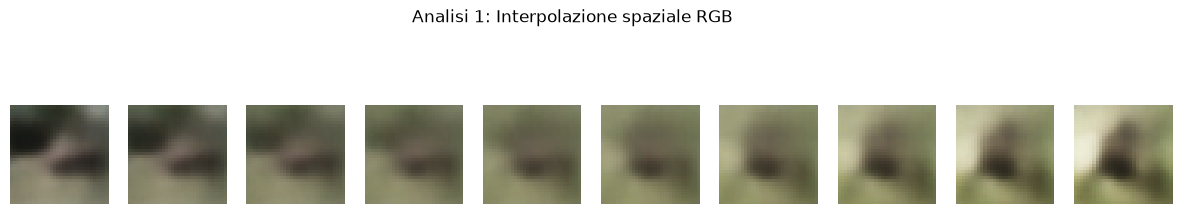

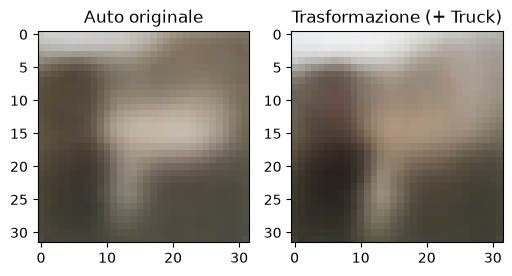

C:\Users\barbara\AppData\Local\Temp\ipykernel_40496\1415402309.py:153: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  quant_dec = torch.quantization.quantize_dynamic(model_cpu.decoder, {nn.Linear}, dtype=torch.qint8)
c:\EPICODE\Epicode_Python_AI_MachineLearning\.venv\Lib\site-packages\torch\ao\nn\quantized\modules\utils.py:72: UserWarning: torch.quantize_per_tensor, torch


Esportazione completata: decoder_cifar_quant.pt pronto.


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# --- CONFIGURAZIONE DEL SISTEMA ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
latent_dim = 128  # Aumentato per gestire la complessità del colore
beta = 2.0        # Bilanciamento tra fedeltà e disentanglement
epochs = 40       # Ciclo di addestramento più lungo per CIFAR-10
batch_size = 64

# Caricamento CIFAR-10 (Immagini RGB 32x32)
transform = transforms.Compose([
    transforms.ToTensor(), # Scalate tra 0.0 e 1.0
])

train_loader = torch.utils.data.DataLoader(
    datasets.CIFAR10('.', train=True, download=True, transform=transform),
    batch_size=batch_size, 
    shuffle=True
)

# --- ARCHITETTURA MODELLO: CifarBVAE ---
class CifarBVAE(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.latent_dim = latent_dim
        
        # Encoder migliorato con Batch Normalization e LeakyReLU
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 4, stride=2, padding=1),  # Out: 32x16x16
            nn.BatchNorm2d(32), # Normalizza l'output per stabilizzare il training
            nn.LeakyReLU(0.2),  # Aiuta il gradiente a fluire meglio rispetto a Relu
            
            nn.Conv2d(32, 64, 4, stride=2, padding=1), # Out: 64x8x8
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),
            
            nn.Conv2d(64, 128, 4, stride=2, padding=1), # Out: 128x4x4
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, latent_dim * 2)      # mu e logvar
        )
        
        # Decoder speculare
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128 * 4 * 4),
            nn.LeakyReLU(0.2),
            nn.Unflatten(1, (128, 4, 4)),
            
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1), # Out: 64x8x8
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),
            
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),  # Out: 32x16x16
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2),
            
            nn.ConvTranspose2d(32, 3, 4, stride=2, padding=1),   # Out: 3x32x32
            nn.Sigmoid() # Restituisce valori [0,1]
        )

    def encode(self, x):
        h = self.encoder(x)
        mu, logvar = h.chunk(2, dim=-1)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decoder(z), mu, logvar
# --- PROCEDURA DI ADDESTRAMENTO ---
model = CifarBVAE(latent_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

print(f"Inizio addestramento su CIFAR-10 per {epochs} epoche...")
model.train()
for epoch in range(epochs):
    total_loss = 0
    for data, _ in train_loader:
        data = data.to(device)
        optimizer.zero_grad()
        
        recon, mu, logvar = model(data)
        
        # Recon Loss (BCE per canali RGB)
        recon_loss = F.binary_cross_entropy(recon, data, reduction='sum')
        # KLD Loss
        kld_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
        
        loss = recon_loss + beta * kld_loss
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    print(f"Epoca {epoch+1}/{epochs} - Perdita: {total_loss/len(train_loader.dataset):.2f}")

# --- ANALISI 1: LATENT WALK ---
@torch.no_grad()
def latent_walk_visualization(model, z1, z2, steps=10):
    model.eval()
    plt.figure(figsize=(15, 3))
    for i, t in enumerate(torch.linspace(0, 1, steps)):
        z = (1 - t) * z1 + t * z2
        img = model.decoder(z).squeeze().cpu().permute(1, 2, 0) # Riordina per HWC (RGB)
        plt.subplot(1, steps, i + 1)
        plt.imshow(img)
        plt.axis('off')
    plt.suptitle("Analisi 1: Interpolazione spaziale RGB")
    plt.show()

# --- ANALISI 2: ALGEBRA DELLE CARATTERISTICHE (Automobile vs Truck) ---
@torch.no_grad()
def feature_algebra_visualization(model, loader):
    model.eval()
    # Classe 1: Automobile, Classe 9: Truck
    z_auto, z_truck = [], []
    for data, labels in loader:
        data = data.to(device)
        mu, _ = model.encode(data)
        z_auto.append(mu[labels == 1])
        z_truck.append(mu[labels == 9])
        if len(z_auto) > 10 and len(z_truck) > 10: break
    
    v_feature = torch.cat(z_truck).mean(0) - torch.cat(z_auto).mean(0)
    z_orig = torch.cat(z_auto)[0:1]
    z_mod = z_orig + 1.5 * v_feature 
    
    plt.figure(figsize=(6, 3))
    plt.subplot(1, 2, 1)
    plt.imshow(model.decoder(z_orig).squeeze().cpu().permute(1, 2, 0))
    plt.title("Auto originale")
    plt.subplot(1, 2, 2)
    plt.imshow(model.decoder(z_mod).squeeze().cpu().permute(1, 2, 0))
    plt.title("Trasformazione (+ Truck)")
    plt.show()

# --- ESPORTAZIONE ---
def export_for_deployment(model):
    model.eval()
    model_cpu = model.cpu()
    # Quantizzazione dei soli layer lineari (per compatibilità con TorchScript)
    quant_dec = torch.quantization.quantize_dynamic(model_cpu.decoder, {nn.Linear}, dtype=torch.qint8)
    example_z = torch.randn(1, latent_dim)
    traced = torch.jit.trace(quant_dec, example_z)
    traced.save("decoder_cifar_quant.pt")
    print("\nEsportazione completata: decoder_cifar_quant.pt pronto.")

# Avvio analisi
z_start = torch.randn(1, latent_dim).to(device)
z_end = torch.randn(1, latent_dim).to(device)
latent_walk_visualization(model, z_start, z_end)
feature_algebra_visualization(model, train_loader)
export_for_deployment(model)